#Integrantes:
  * Nicolás Fonseca
  * Bastián Rubio

# 1.- Importación de librerías y carga del dataset
Comenzamos importando la librería necesaria y cargando los datos de la Play Store.

In [1]:
import pandas as pd

# Cargamos el dataset
df_original = pd.read_csv('/content/googleplaystore.csv')

# 2.- Exploración Inicial
Visualizamos la estructura de las columnas, la cantidad y el tipo de datos para entender los problemas a resolver.

In [2]:
# Vista previa de las primeras 5 filas
display(df_original.head())

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [3]:
# Información general del dataframe
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [4]:
'''
Hacer la copia del DataSet por si mas adelante se corrompe.
'''

df = df_original.copy()

In [5]:
# Verificación de calidad: nulos, duplicados y tamaño original
print(f'Columnas con datos nulos: \n{df.isnull().sum()}\n')
print(f'Filas duplicadas en todo el dataset: {df.duplicated().sum()}\n')
print(f'Total de filas dataset sin editar: {len(df)}\n')

print("--- Duplicados por columna ---")
for col in df.columns:
    n_duplicados = df[col].duplicated().sum()
    print(f"{col:20} → {n_duplicados} duplicados")

Columnas con datos nulos: 
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

Filas duplicadas en todo el dataset: 483

Total de filas dataset sin editar: 10841

--- Duplicados por columna ---
App                  → 1181 duplicados
Category             → 10807 duplicados
Rating               → 10800 duplicados
Reviews              → 4839 duplicados
Size                 → 10379 duplicados
Installs             → 10819 duplicados
Type                 → 10837 duplicados
Price                → 10748 duplicados
Content Rating       → 10834 duplicados
Genres               → 10721 duplicados
Last Updated         → 9463 duplicados
Current Ver          → 8008 duplicados
Android Ver          → 10807 duplicados


> **Observación:** La columna `App` tiene muchos duplicados. Comprobamos que estos duplicados se repiten, por ende es posible eliminarlos sin perder información sensible. Es importante hacerlo ahora para que no afecten los cálculos estadísticos posteriores.

# 3.- Eliminación de duplicados
La columna `App` tiene muchos duplicados. Los eliminamos ahora para que no sesguen los cálculos estadísticos posteriores (como la mediana).

In [6]:
# Eliminamos duplicados basados en el nombre de la aplicación
df.drop_duplicates(subset=["App"], inplace=True)

# Comprobamos que ya no existen duplicados en 'App'
print(f"Duplicados restantes en 'App': {df['App'].duplicated().sum()}")

Duplicados restantes en 'App': 0


# 4.- Imputación de datos faltantes en Rating
Rellenamos los datos nulos en la columna `Rating` utilizando la mediana del dataset limpio de duplicados.

In [7]:
# Imputamos los valores nulos de Rating con la mediana
df['Rating'] = df['Rating'].fillna(df['Rating'].median())

# Verificamos que ya no hay nulos y vemos los estadísticos básicos
print("Nulos en Rating:", df['Rating'].isnull().sum(), "\n")
print(df['Rating'].describe())

Nulos en Rating: 0 

count    9660.000000
mean        4.193975
std         0.518732
min         1.000000
25%         4.000000
50%         4.300000
75%         4.500000
max        19.000000
Name: Rating, dtype: float64


# 5.- Limpieza de columnas Installs, Price, Reviews y Category
Eliminamos los símbolos como ( + , $ _) para poder convertir estas columnas a formato numérico, o corregirlas.

In [8]:
# Limpieza de Installs
df['Installs'] = df['Installs'].str.replace('+', '', regex=False).str.replace(',', '', regex=False)
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

# Limpieza de Price (eliminamos el símbolo $)
df['Price'] = df['Price'].str.replace('$', '', regex=False)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

print("Tipos de datos actualizados:")
print(df[['Installs', 'Price']].dtypes)

Tipos de datos actualizados:
Installs    float64
Price       float64
dtype: object


In [9]:
'''
Convertir Reviews a Number
'''

#Transformar Columna Reviews a Number
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')
print("Tipos de datos actualizados:")
print(df[['Reviews']].dtypes)

Tipos de datos actualizados:
Reviews    float64
dtype: object


In [ ]:
# Ver los valores únicos antes y después
print("Antes de los Cambios a la Columna Category:")
print(df["Category"].unique())

df["Category"] = df["Category"].str.replace("_", " ").str.title()

print("\nDespués de los Cambios a la Columna Category:")
print(df["Category"].unique())

Antes de los Cambios a la Columna Category:
['ART_AND_DESIGN' 'AUTO_AND_VEHICLES' 'BEAUTY' 'BOOKS_AND_REFERENCE'
 'BUSINESS' 'COMICS' 'COMMUNICATION' 'DATING' 'EDUCATION' 'ENTERTAINMENT'
 'EVENTS' 'FINANCE' 'FOOD_AND_DRINK' 'HEALTH_AND_FITNESS' 'HOUSE_AND_HOME'
 'LIBRARIES_AND_DEMO' 'LIFESTYLE' 'GAME' 'FAMILY' 'MEDICAL' 'SOCIAL'
 'SHOPPING' 'PHOTOGRAPHY' 'SPORTS' 'TRAVEL_AND_LOCAL' 'TOOLS'
 'PERSONALIZATION' 'PRODUCTIVITY' 'PARENTING' 'WEATHER' 'VIDEO_PLAYERS'
 'NEWS_AND_MAGAZINES' 'MAPS_AND_NAVIGATION' '1.9']

Después de los Cambios a la Columna Category:
['Art And Design' 'Auto And Vehicles' 'Beauty' 'Books And Reference'
 'Business' 'Comics' 'Communication' 'Dating' 'Education' 'Entertainment'
 'Events' 'Finance' 'Food And Drink' 'Health And Fitness' 'House And Home'
 'Libraries And Demo' 'Lifestyle' 'Game' 'Family' 'Medical' 'Social'
 'Shopping' 'Photography' 'Sports' 'Travel And Local' 'Tools'
 'Personalization' 'Productivity' 'Parenting' 'Weather' 'Video Players'
 'News And Magaz

# 6.- Transformación de Fechas (Last Updated)
Convertimos la columna `Last Updated` a un formato de tiempo real (datetime) para su correcto manejo.

In [10]:
# Convertimos el texto a datetime
df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')

display(df[['App', 'Last Updated']].head())

,App,Last Updated
0,Photo Editor & Candy Camera & Grid & ScrapBook,2018-01-07
1,Coloring book moana,2018-01-15
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",2018-08-01
3,Sketch - Draw & Paint,2018-06-08
4,Pixel Draw - Number Art Coloring Book,2018-06-20


# 7.- Tratamiento de Outliers en Rating
Utilizamos el Rango Intercuartílico (IQR) para filtrar valores atípicos extremos en las valoraciones.

In [11]:
# Calculamos los cuartiles y el rango intercuartílico (IQR) para la columna Rating
Q1 = df['Rating'].quantile(0.25)
Q3 = df['Rating'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Sobrescribimos el df conservando solo los valores dentro de los límites normales
df = df[(df['Rating'] >= limite_inferior) & (df['Rating'] <= limite_superior)]

print(f"Filas resultantes tras eliminar outliers: {len(df)}")

Filas resultantes tras eliminar outliers: 9167


In [12]:
print(f'Columnas con datos nulos: \n{df.isnull().sum()}\n')

Columnas con datos nulos: 
App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              1
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       7
Android Ver       2
dtype: int64



In [13]:
df[df['Last Updated'].isnull()][['App','Android Ver', 'Last Updated', 'Installs']]

,App,Android Ver,Last Updated,Installs


In [14]:
df[df['Content Rating'].isnull()][['App','Android Ver', 'Last Updated', 'Installs']]

,App,Android Ver,Last Updated,Installs


In [15]:
df[df['Price'].isnull()][['App','Android Ver', 'Last Updated', 'Installs']]

,App,Android Ver,Last Updated,Installs


In [16]:
df[df['Installs'].isnull()][['App','Android Ver', 'Last Updated', 'Installs']]

,App,Android Ver,Last Updated,Installs


In [17]:
df[df['Type'].isnull()][['App','Android Ver', 'Last Updated', 'Installs']]

,App,Android Ver,Last Updated,Installs
9148,Command & Conquer: Rivals,Varies with device,2018-06-28,0.0


In [18]:
#Ver solo la columna Android Ver con su índice con los valores NaN y que App es
df[df['Android Ver'].isnull()][['App', 'Android Ver', 'Last Updated', 'Installs']]

,App,Android Ver,Last Updated,Installs
4453,[substratum] Vacuum: P,NaN,2018-07-20,1000.0
4490,Pi Dark [substratum],NaN,2018-03-27,10000.0


In [19]:
#Ver solo la columna Android Ver con su índice con los valores NaN y que App es
df[df['Current Ver'].isnull()][['App', 'Current Ver', 'Last Updated']]

,App,Current Ver,Last Updated
1553,Market Update Helper,NaN,2013-02-12
6322,Virtual DJ Sound Mixer,NaN,2017-05-10
6803,BT Master,NaN,2016-11-06
7333,Dots puzzle,NaN,2018-04-18
7407,Calculate My IQ,NaN,2017-04-03
7730,UFO-CQ,NaN,2016-07-04
10342,La Fe de Jesus,NaN,2017-01-31


In [20]:
df[df['Type'].isnull()][['App', 'Type', 'Last Updated']]

,App,Type,Last Updated
9148,Command & Conquer: Rivals,NaN,2018-06-28


* Verificamos que los datos nulos restantes son aplicaciones desactualizadas y con descargar inferiores a 10.000. Estas pueden ser eliminadas sin afectar a la información importante.

In [21]:
#eliminamos los datos verificados
df.dropna(subset=['Type','Current Ver','Android Ver'], inplace=True)

# 8.- Verificación Final del Dataset
Comprobamos la estructura final después de todo el pipeline de limpieza para asegurar que los datos estén listos para el análisis.

In [22]:
# Validamos la info general y la estadística descriptiva final
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9157 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             9157 non-null   object        
 1   Category        9157 non-null   object        
 2   Rating          9157 non-null   float64       
 3   Reviews         9157 non-null   float64       
 4   Size            9157 non-null   object        
 5   Installs        9157 non-null   float64       
 6   Type            9157 non-null   object        
 7   Price           9157 non-null   float64       
 8   Content Rating  9157 non-null   object        
 9   Genres          9157 non-null   object        
 10  Last Updated    9157 non-null   datetime64[ns]
 11  Current Ver     9157 non-null   object        
 12  Android Ver     9157 non-null   object        
dtypes: datetime64[ns](1), float64(4), object(8)
memory usage: 1001.5+ KB


# 9. Graficación de los datos relevantes.

In [25]:
# ============================================================
# Manipulación en Pandas
# Agrupación con múltiples métricas + filtro con condiciones
# ============================================================

# ── 9.1 Agrupación: resumen por categoría ────────────────────
  # groupby agrupa las filas por categoría.
    # agg calcula varias métricas a la vez sobre cada grupo.
resumen = (
    df.groupby('Category')
    .agg(
        Total_Apps   = ('App',     'count'),   # cantidad de apps
        Rating_Prom  = ('Rating',  'mean'),     # rating promedio
        Installs_Sum = ('Installs','sum')        # total instalaciones
    )
    .round(2)
    .sort_values('Installs_Sum', ascending=False)  # ordenar por más descargadas
    .head(5)                                        # mostrar solo el top 5
)
# Muestra el número completo con puntos de miles: 13.873.347.000
  #Si no ocupamos esto el resultado nos aparecera asi: 1.387347e+10
resumen['Installs_Sum'] = resumen['Installs_Sum'].apply(lambda x: f"{x:,.0f}")

print("=== Top 5 Categorías ===")
print(resumen.to_string())

# ── 9.2 Filtro avanzado con múltiples condiciones ────────────
  # Buscamos apps que cumplan los 3 criterios a la vez:
    # gratuitas, con más de 1 millón de instalaciones y rating alto.
apps_top = df[
    (df['Type']     == 'Free')      &   # condición 1: gratuita
    (df['Installs'] >= 1_000_000)   &   # condición 2: +1M instalaciones
    (df['Rating']   >= 4.5)             # condición 3: rating alto
][['App', 'Category', 'Rating', 'Installs']].head(5)

print("\n=== Apps Free, +1M installs, Rating ≥ 4.5 ===")
print(apps_top.to_string(index=False))

=== Top 5 Categorías ===
               Total_Apps  Rating_Prom    Installs_Sum
Category                                              
GAME                  944         4.28  13,873,466,915
COMMUNICATION         305         4.21  11,038,020,151
TOOLS                 755         4.21   7,914,905,655
PRODUCTIVITY          353         4.29   5,776,331,669
SOCIAL                231         4.30   5,487,789,802

=== Apps Free, +1M installs, Rating ≥ 4.5 ===
                                               App          Category  Rating   Installs
U Launcher Lite – FREE Live Cool Themes, Hide Apps    ART_AND_DESIGN     4.7  5000000.0
                             Sketch - Draw & Paint    ART_AND_DESIGN     4.5 50000000.0
                                      ibis Paint X    ART_AND_DESIGN     4.6 10000000.0
Canva: Poster, banner, card maker & graphic design    ART_AND_DESIGN     4.7 10000000.0
                     Used Cars and Trucks for Sale AUTO_AND_VEHICLES     4.6  1000000.0


/tmp/ipykernel_1983/983667786.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values, y=top10.index, ax=axes[0], palette='colorblind')


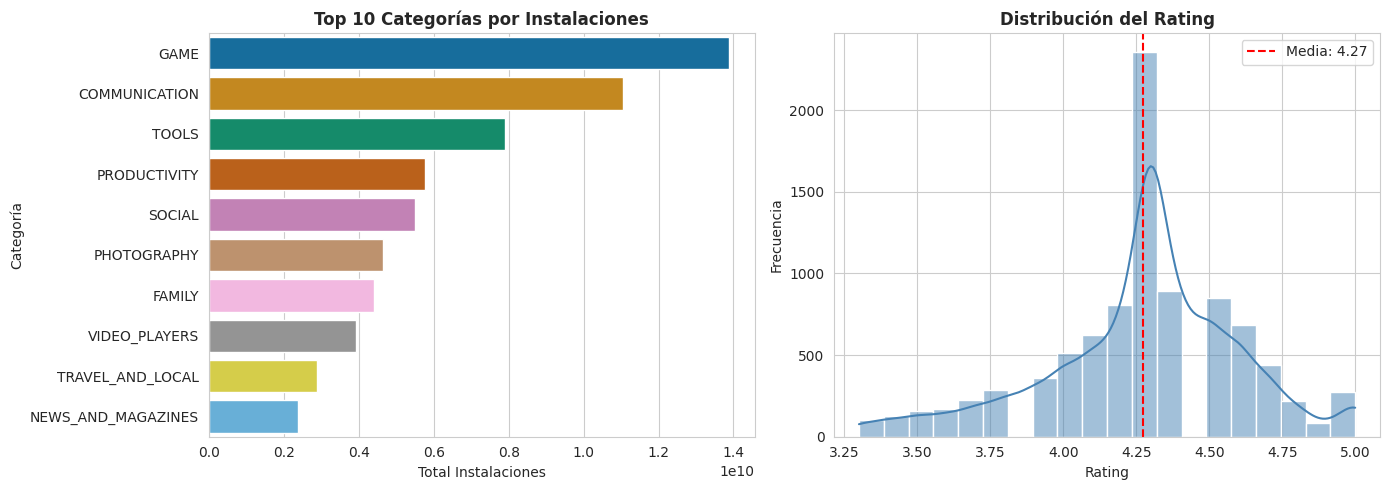

In [24]:
# ============================================================
# Reportes y Visualizaciones
# 2 gráficos: categorías con más descargas + distribución rating
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Gráfico 1: Top 10 categorías por instalaciones ───────────
top10 = (
    df.groupby('Category')['Installs']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

sns.barplot(x=top10.values, y=top10.index, ax=axes[0], palette='colorblind')
axes[0].set_title('Top 10 Categorías por Instalaciones', fontweight='bold')
axes[0].set_xlabel('Total Instalaciones')
axes[0].set_ylabel('Categoría')

# ── Gráfico 2: Distribución del Rating ───────────────────────
sns.histplot(df['Rating'], bins=20, kde=True, ax=axes[1], color='steelblue')
axes[1].axvline(df['Rating'].mean(), color='red', linestyle='--',
                label=f"Media: {df['Rating'].mean():.2f}")
axes[1].set_title('Distribución del Rating', fontweight='bold')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.savefig('visualizaciones.png', dpi=150)
plt.show()



# 10.- Transformaciones Avanzadas

In [ ]:
# ============================================================
# Transformaciones Avanzadas
# pivot_table, melt, vectorización np.where, broadcasting NumPy
# ============================================================

# ── 10.1 pivot_table ────
# Tabla dinámica: rating promedio según categoría y tipo de app
  # pivot_table es equivalente a una tabla dinámica de Excel.
    # Permite cruzar dos variables categóricas y agregar una numérica.
tabla_pivot = df.pivot_table(
    index='Category',
    columns='Type',
    values='Rating',
    aggfunc='mean'
).round(2)
tabla_pivot = tabla_pivot.fillna(tabla_pivot.mean()).round(2)

print("=== pivot_table: Rating promedio por Categoría y Tipo ===")
print(tabla_pivot.head(5).to_string())
# → Permite comparar directamente el rating de apps Free vs Paid
  #   dentro de cada categoría.


=== pivot_table: Rating promedio por Categoría y Tipo ===
Type                 Free  Paid
Category                       
Art And Design       4.36  4.73
Auto And Vehicles    4.30  4.40
Beauty               4.31  4.38
Books And Reference  4.35  4.34
Business             4.29  4.25


In [ ]:

# ── 10.2 melt: Transformar de formato ancho a largo ────────────
  # melt hace el proceso inverso al pivot: pasa columnas a filas.
    # Es útil para graficar múltiples métricas en un mismo eje.
df_metricas = df[['App', 'Rating', 'Reviews', 'Installs']].head(10)

df_largo = df_metricas.melt(
    id_vars='App',                            # columna que se mantiene como ID
    value_vars=['Rating', 'Reviews', 'Installs'],  # columnas que se transforman a filas
    var_name='Metrica',                       # nombre de la columna de etiquetas
    value_name='Valor'                        # nombre de la columna de valores
)

print("\n=== melt: Formato largo (primeras 9 filas) ===")
print(df_largo.head(5).to_string(index=False))




=== melt: Formato largo (primeras 9 filas) ===
                                               App Metrica  Valor
    Photo Editor & Candy Camera & Grid & ScrapBook  Rating    4.1
                               Coloring book moana  Rating    3.9
U Launcher Lite – FREE Live Cool Themes, Hide Apps  Rating    4.7
                             Sketch - Draw & Paint  Rating    4.5
             Pixel Draw - Number Art Coloring Book  Rating    4.3


In [ ]:
import numpy as np
# ── 10.3 np.where: Vectorización (equivale a IF anidado) ───────
  # Clasifica apps según instalaciones sin usar loops
    # Es más eficiente que apply() porque opera sobre arrays
df['Popularidad'] = np.where(df['Installs'] >= 1_000_000, 'Alta', 'Baja')
print("\n=== np.where: Popularidad ===")
print(df['Popularidad'].value_counts())




=== np.where: Popularidad ===
Popularidad
Baja    5803
Alta    3354
Name: count, dtype: int64


In [ ]:
# ── 10.4 Broadcasting NumPy: Score compuesto ───────────────────
# Broadcasting permite aplicar operaciones matemáticas entre arrays
  # Operación matemática directa entre dos arrays NumPy
    # Combina rating e instalaciones en un score único
df['Score'] = df['Rating'].to_numpy() * np.log1p(df['Installs'].to_numpy()).round(1)

print("\n=== Broadcasting: Score compuesto ===")
print(df[['App', 'Rating', 'Score']].head(3).to_string(index=False))


=== Broadcasting: Score compuesto ===
                                               App  Rating  Score
    Photo Editor & Candy Camera & Grid & ScrapBook     4.1  37.72
                               Coloring book moana     3.9  51.09
U Launcher Lite – FREE Live Cool Themes, Hide Apps     4.7  72.38


# 11. Verificación de Integridad

In [ ]:
# ============================================================
# Verificación de Integridad
# Se definen 3 funciones para auditar el dataset final:
#   1. auditar_dataset  → revisa nulos y unicidad por columna
#   2. validar_rangos   → verifica que los valores tengan sentido
#   3. verificar_consistencia → cruza columnas para detectar contradicciones
# ============================================================

def auditar_dataset(df: pd.DataFrame) -> pd.DataFrame:
    """Revisa cada columna del dataset y genera un reporte de calidad.

    Para cada columna informa: tipo de dato, cantidad de nulos,
    porcentaje de nulos, duplicados, valores únicos y un estado
    visual (OK o Con nulos).

    Args:
        df: El DataFrame a auditar.

    Returns:
        Un DataFrame con una fila por columna y sus métricas de calidad.
    """
    reporte = []
    for col in df.columns:
        total      = len(df)
        nulos      = df[col].isnull().sum()
        pct_nulos  = round(nulos / total * 100, 2)
        duplicados = df[col].duplicated().sum()
        unicos     = df[col].nunique()
        tipo       = str(df[col].dtype)

        reporte.append({
            'Columna'   : col,
            'Tipo'      : tipo,
            'Nulos'     : nulos,
            '% Nulos'   : pct_nulos,
            'Duplicados': duplicados,
            'Únicos'    : unicos,
            'Estado'    : '✅ OK' if nulos == 0 else '⚠️ Con nulos'
        })
    return pd.DataFrame(reporte)


def validar_rangos(df: pd.DataFrame) -> pd.DataFrame:
    """Verifica que las columnas numéricas tengan valores dentro de rangos válidos.

    Aplica reglas de negocio básicas: el Rating debe estar entre 1 y 5,
    y los valores de Price, Installs y Reviews no pueden ser negativos.

    Args:
        df: El DataFrame a validar.

    Returns:
        Un DataFrame con el resultado de cada regla: cuántas filas cumplen,
        cuántas violan la regla y el porcentaje de cumplimiento.
    """
     # Cada regla es una tupla: (columna, condición booleana, descripción)
    reglas = [
        ('Rating',   df['Rating'].between(1, 5),  'Rating entre 1 y 5'),
        ('Price',    df['Price'] >= 0,             'Price no negativo'),
        ('Installs', df['Installs'] >= 0,          'Installs no negativo'),
        ('Reviews',  df['Reviews'] >= 0,           'Reviews no negativo'),
    ]

    resultados = []
    for col, condicion, descripcion in reglas:
        total     = len(df)
        cumple    = condicion.sum()
        no_cumple = total - cumple
        resultados.append({
            'Regla'        : descripcion,
            'Total Filas'  : total,
            'Cumplen'      : cumple,
            'Violan'       : no_cumple,
            'Cumplimiento' : f"{round(cumple / total * 100, 2)}%",
            'Estado'       : '✅ PASS' if no_cumple == 0 else '❌ FAIL'
        })
    return pd.DataFrame(resultados)


def verificar_consistencia(df: pd.DataFrame) -> pd.DataFrame:
    """Detecta registros que violan una regla lógica entre columnas.

    Regla aplicada: si una app es 'Free', su Price debe ser 0.
    Cualquier app marcada como gratuita con precio mayor a 0 es un error.

    Args:
        df: El DataFrame a verificar.

    Returns:
        Un DataFrame con las filas inconsistentes. Si está vacío, no hay errores.
    """
    inconsistentes = df[
        (df['Type'] == 'Free') & (df['Price'] > 0)
    ][['App', 'Type', 'Price']]

    return inconsistentes


# ── Ejecutar las tres verificaciones ─────────────────────────
print("=" * 55)
print("  AUDITORÍA DE INTEGRIDAD — Google Play Store")
print("=" * 55)

# 1. Reporte columna por columna
reporte_auditoria = auditar_dataset(df)
print("\n📋 REPORTE POR COLUMNA:")
print(reporte_auditoria.to_string(index=False))

# 2. Validación de rangos
reporte_rangos = validar_rangos(df)
print("\n🔍 VALIDACIÓN DE RANGOS:")
print(reporte_rangos.to_string(index=False))

# 3. Consistencia lógica
inconsistentes = verificar_consistencia(df)
print(f"\n⚖️ CONSISTENCIA LÓGICA (Free con Price > 0):")
if len(inconsistentes) == 0:
    print("  ✅ Sin inconsistencias detectadas.")
else:
    print(f"  ❌ {len(inconsistentes)} casos inconsistentes:")
    print(inconsistentes.to_string(index=False))

# 4. Score general de integridad
checks_ok   = (reporte_rangos['Estado'] == '✅ PASS').sum()
total_checks = len(reporte_rangos)
nulos_total  = reporte_auditoria['Nulos'].sum()
score        = round(checks_ok / total_checks * 100, 1)

print(f"\n📊 SCORE GENERAL DE INTEGRIDAD:")
print(f"  Reglas de rango aprobadas  : {checks_ok}/{total_checks}")
print(f"  Nulos totales en el dataset: {nulos_total}")
print(f"  Score de integridad        : {score}%")

  AUDITORÍA DE INTEGRIDAD — Google Play Store

📋 REPORTE POR COLUMNA:
       Columna           Tipo  Nulos  % Nulos  Duplicados  Únicos Estado
           App         object      0      0.0           0    9157   ✅ OK
      Category         object      0      0.0        9124      33   ✅ OK
        Rating        float64      0      0.0        9139      18   ✅ OK
       Reviews        float64      0      0.0        3933    5224   ✅ OK
          Size         object      0      0.0        8718     439   ✅ OK
      Installs        float64      0      0.0        9137      20   ✅ OK
          Type         object      0      0.0        9155       2   ✅ OK
         Price        float64      0      0.0        9067      90   ✅ OK
Content Rating         object      0      0.0        9151       6   ✅ OK
        Genres         object      0      0.0        9039     118   ✅ OK
  Last Updated datetime64[ns]      0      0.0        7810    1347   ✅ OK
   Current Ver         object      0      0.0        6